In [2]:
import h3 
import xarray as xr
import rasterio
from shapely.geometry import Polygon
import geopandas as gpd
import numpy as np
import os
import pandas as pd
import data_prep as dp
from ahp import Transformer

%load_ext autoreload
%autoreload 2

In [31]:
pastos = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-012-A')
manglares = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-020-A')
coralinas = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-021-A')

In [51]:
coralinas.iloc[0,:]

Phylum                         Cnidaria
Class                      Hexacorallia
Subclass                            NaN
Order                      Scleractinia
Suborder                       Vacatina
Family                     Astrangiidae
Subfamily                           NaN
Genus                         Astrangia
Subgenus                            NaN
Species                        conferta
Subspecies                          NaN
Ocean                     North Pacific
Locality                            NaN
Latitude                            6.6
Longitude                        -77.45
DepthInMet                        119.0
Density                          -999.0
EndLatitud                       -999.0
EndLongitu                       -999.0
Temperatur                       -999.0
Salinity                         -999.0
Oxygen                           -999.0
pH                               -999.0
geometry      MULTIPOINT ((-77.45 6.6))
Name: 0, dtype: object

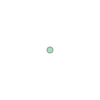

In [50]:
coralinas.iloc[0,:].geometry.convex_hull

# 32-33

In [ ]:
imma = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-032-A')
kbas = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-033-A')
# imma = imma['geometry']
# kbas = kbas['geometry']
imma['origen'] = 'IMMA'
kbas['origen'] = 'KBAs'

if imma.crs != kbas.crs:
    kbas = kbas.to_crs(imma.crs)

# 3. Perform the Overlap (Union)
# Options for 'how' are: 'union', 'intersection', 'identity', 'symmetric_difference'
single_layer = gpd.overlay(imma, kbas, how='union')

# 4. Save the result
single_layer.to_file("combined_polygons", driver='ESRI Shapefile')


In [29]:
import pandas as pd
import numpy as np

# ... (your existing code for loading and crs alignment)

# 3. Perform the Overlap (Union)
# By default, overlapping columns get suffixes '_1' (left) and '_2' (right)
single_layer = gpd.overlay(imma, kbas, how='union', keep_geom_type=True)

# 4. Create the consolidated 'source' column
# We check if the polygon came from IMMA, KBAs, or Both
conditions = [
    (single_layer['origen_1'].notna() & single_layer['origen_2'].isna()),
    (single_layer['origen_1'].isna() & single_layer['origen_2'].notna()),
    (single_layer['origen_1'].notna() & single_layer['origen_2'].notna())
]

choices = ['IMMA', 'KBAs', 'KBAs, IMMA']

single_layer['found_in'] = np.select(conditions, choices, default='Unknown')
single_layer = single_layer.drop(['origen_1','origen_2'], axis = 1 )

# 5. Save the result
single_layer.to_file("combined_polygons/combined_polygons.shp")

In [38]:
single_layer.head()

,Status,SitRecID,Region,Country,ISO3,NatName,IntName,SitLat,SitLong,SitAreaKM2,...,IbaStatus,LegacyKba,AzeStatus,LastUpdate,Source,DelTxt,Shape_Leng,Shape_Area,geometry,found_in
0,IMMA,14423.0,South America,Colombia,COL,Capurganá,Capurganá,8.640083,-77.356608,11.887767,...,confirmed,NaN,NaN,2008,IBA Directory Process,NaN,0.0,0.0,"MULTIPOLYGON (((-77.34236 8.62856, -77.34236 8...","KBAs, IMMA"
1,IMMA,200673.0,South America,Colombia,COL,Bajo Baudó,Bajo Baudo,4.962629,-77.403450,3145.671218,...,NaN,NaN,NaN,2023,WDKBA,This site was delineated according to the limi...,0.0,0.0,"POLYGON ((-77.52459 5.50132, -77.52649 5.49895...","KBAs, IMMA"
2,IMMA,19085.0,South America,Colombia,COL,Parque Nacional Natural Gorgona,National Natural Park Gorgona,2.971993,-78.205676,601.019656,...,confirmed,NaN,NaN,2023,INSTITUTO HUMBOLDT,The limits of this KBA are given by the area a...,0.0,0.0,"POLYGON ((-78.09684 2.93064, -78.23018 2.81397...","KBAs, IMMA"
3,IMMA,19088.0,South America,Colombia,COL,Parque Nacional Natural Sanquianga,National Natural Park Sanquianga,2.537717,-78.303528,865.160467,...,confirmed,NaN,NaN,2023,INSTITUTO HUMBOLDT,The delimitation of this KBA is given by the a...,0.0,0.0,"MULTIPOLYGON (((-78.12362 2.61508, -78.12362 2...","KBAs, IMMA"
4,IMMA,14454.0,South America,Colombia,COL,Parque Nacional Natural Utría,Utría Natural National Park,5.998430,-77.261974,643.274630,...,confirmed,NaN,NaN,2023,INSTITUTO HUMBOLDT,This KBA follows the exact boundaries of the p...,0.0,0.0,"MULTIPOLYGON (((-77.38053 6.05247, -77.3793 6....","KBAs, IMMA"


In [40]:
single_layer[['geometry','found_in']].to_file("32-33/combined_polygons.shp")

# 14 - 20 - 21

In [3]:
manglares = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-014-A')
pastos = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-020-A')
coralinas = gpd.read_file('/home/choclo/documents/ahpAmbiental/vars_ambiental_ahp/AMB-021-A')


In [16]:
coralinas

,Phylum,Class,Subclass,Order,Suborder,Family,Subfamily,Genus,Subgenus,Species,...,Longitude,DepthInMet,Density,EndLatitud,EndLongitu,Temperatur,Salinity,Oxygen,pH,geometry
0,Cnidaria,Hexacorallia,NaN,Scleractinia,Vacatina,Astrangiidae,NaN,Astrangia,NaN,conferta,...,-77.4500,119.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-77.45 6.6))
1,Cnidaria,Hexacorallia,NaN,Scleractinia,Refertina,Fungiacyathidae,NaN,Fungiacyathus,Fungiacyathus (Bathyactis),marenzelleri,...,-82.1333,2070.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-82.1333 3.15))
2,Porifera,Hexactinellida,Hexasterophora,Sceptrulophora,NaN,Euretidae,Chonelasmatinae,Bathyxiphus,NaN,NaN,...,-81.5167,1644.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-81.5167 4.05))
3,Porifera,Hexactinellida,Hexasterophora,Sceptrulophora,NaN,Sceptrulophora incertae sedis,NaN,Conorete,NaN,erectum,...,-81.5167,1644.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-81.5167 4.05))
4,Porifera,Hexactinellida,Hexasterophora,Sceptrulophora,NaN,Sceptrulophora incertae sedis,NaN,Conorete,NaN,erectum,...,-81.5167,1644.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-81.5167 4.05))
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,Cnidaria,Octocorallia,NaN,Scleralcyonacea,NaN,Spongiodermidae,NaN,Diodogorgia,NaN,NaN,...,-74.5000,18.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-74.5 11.0667))
315,Cnidaria,Octocorallia,NaN,Scleralcyonacea,NaN,Virgulariidae,NaN,Acanthoptilum,NaN,NaN,...,-75.0833,38.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-75.0833 11.0167))
316,Cnidaria,Octocorallia,NaN,Scleralcyonacea,NaN,Renillidae,NaN,Renilla,NaN,muelleri,...,-71.8700,22.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-71.87 12.4))
317,Cnidaria,Octocorallia,NaN,Scleralcyonacea,NaN,Spongiodermidae,NaN,Diodogorgia,NaN,NaN,...,-71.8700,22.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,MULTIPOINT ((-71.87 12.4))
